In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

%matplotlib inline

rs = 123

In [2]:
course_df = pd.read_csv(r"./data/course_genre.csv")
ratings_df = pd.read_csv(r"./data/ratings.csv")

In [3]:
( course_df.columns,
course_df.shape[0],
course_df.head(),
course_df.dtypes,
course_df.iloc[1, ]
)

(Index(['COURSE_ID', 'TITLE', 'Database', 'Python', 'CloudComputing',
        'DataAnalysis', 'Containers', 'MachineLearning', 'ComputerVision',
        'DataScience', 'BigData', 'Chatbot', 'R', 'BackendDev', 'FrontendDev',
        'Blockchain'],
       dtype='object'),
 307,
     COURSE_ID                                              TITLE  Database  \
 0    ML0201EN  robots are coming  build iot apps with watson ...         0   
 1    ML0122EN                accelerating deep learning with gpu         0   
 2  GPXX0ZG0EN  consuming restful services using the reactive ...         0   
 3    RP0105EN         analyzing big data in r using apache spark         1   
 4  GPXX0Z2PEN  containerizing  packaging  and running a sprin...         0   
 
    Python  CloudComputing  DataAnalysis  Containers  MachineLearning  \
 0       0               0             0           0                0   
 1       1               0             0           0                1   
 2       0               0  

## Wordcloud

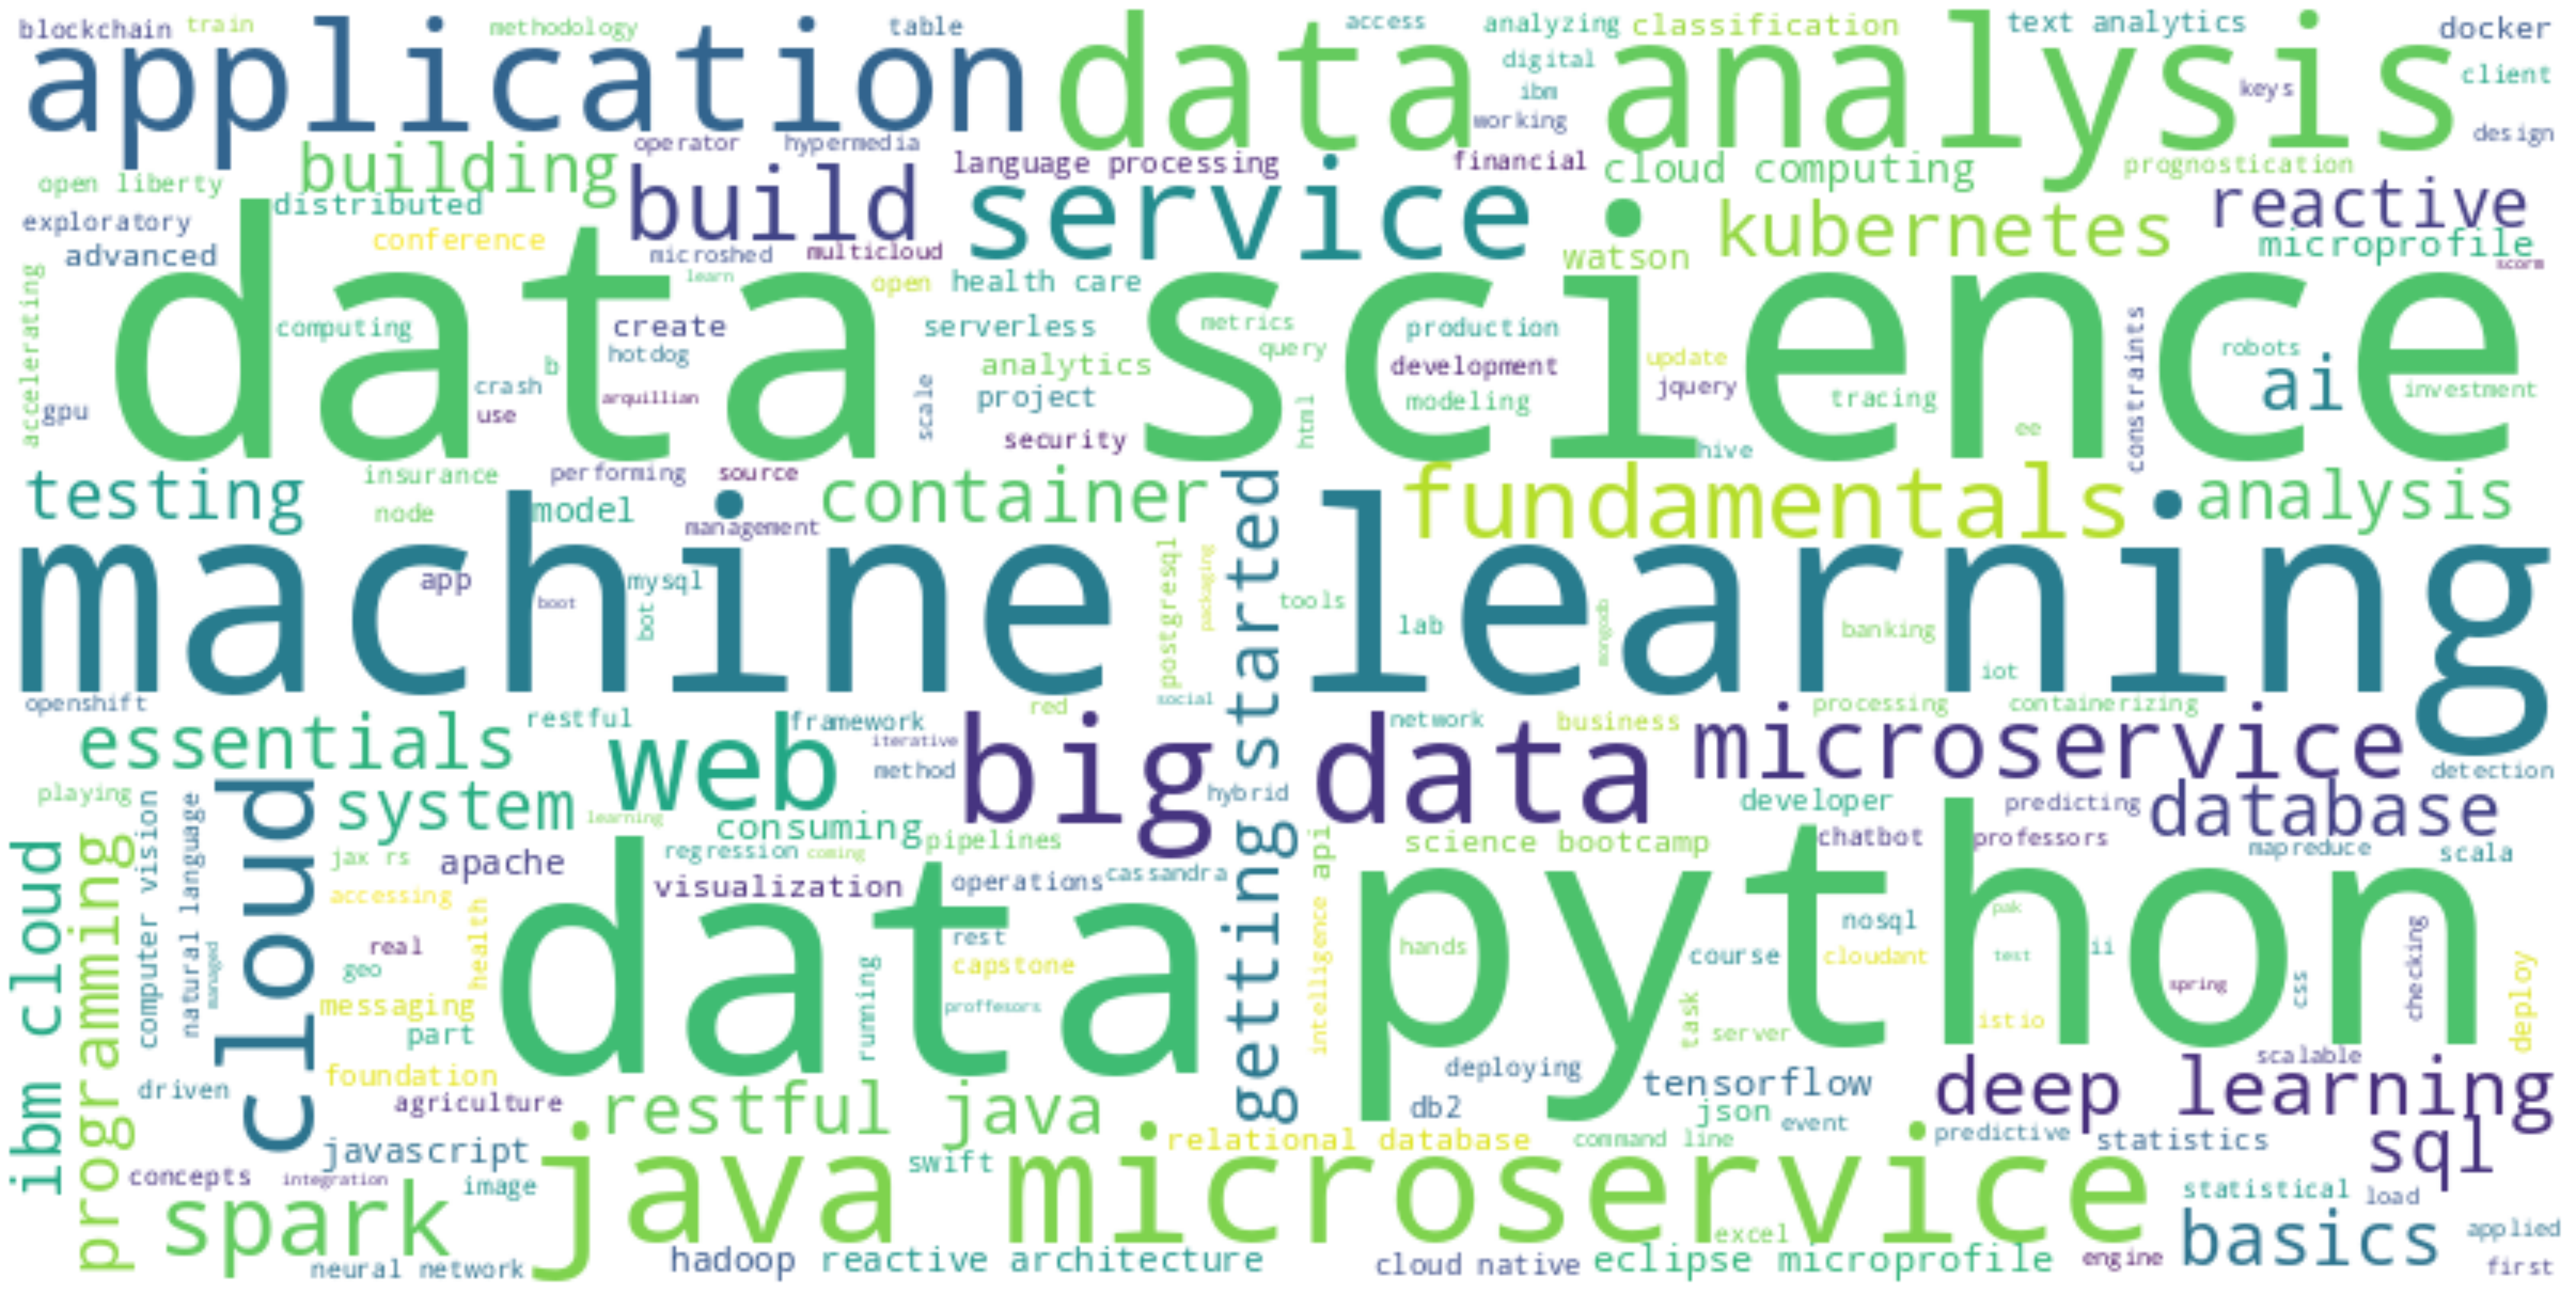

In [4]:
titles = " ".join(title for title in course_df['TITLE'].astype(str))

# English Stopwords
stopwords = set(STOPWORDS)
stopwords.update(["getting started", "using", "enabling", "template", "university", "end", "introduction", "basic"])

wordcloud = WordCloud(stopwords=stopwords, background_color="white", width=800, height=400)
wordcloud.generate(titles)

# Create a new figure with a specified size
plt.figure(figsize=(40,20))
# Disable axis display
plt.axis("off")
# Adjust the layout to ensure tight spacing
plt.tight_layout(pad=0)
# Display the word cloud image with bilinear interpolation
plt.imshow(wordcloud, interpolation='bilinear')

In [5]:
ml_subset = course_df[course_df["MachineLearning"] == 1]
ml_subset.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
15,DAI101EN,data ai essentials,0,0,0,0,0,1,0,0,0,0,0,0,0,0
19,HCC105EN,ybrid cloud conference ai pipelines lab,0,0,0,0,0,1,0,0,0,0,0,0,0,0
21,DS0132EN,data ai jumpstart your journey,0,0,0,0,0,1,0,0,0,0,0,0,0,0
24,BENTEST4,ai for everyone master the basics,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [6]:
ml_bd_subset = ml_subset[ml_subset["BigData"] == 1]
ml_bd_subset.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
46,GPXX0BUBEN,insurance risk assessment with montecarlo meth...,0,0,0,0,0,1,0,0,1,0,0,0,0,0
59,TA0106EN,text analytics at scale,0,0,0,0,0,1,0,1,1,0,0,0,0,0
184,BD0221EN,spark mllib,0,0,0,0,0,1,0,0,1,0,0,0,0,0
282,excourse69,machine learning with big data,0,0,0,0,0,1,0,0,1,0,0,0,0,0


In [7]:
genres = course_df.columns[2:]
genres

Index(['Database', 'Python', 'CloudComputing', 'DataAnalysis', 'Containers',
       'MachineLearning', 'ComputerVision', 'DataScience', 'BigData',
       'Chatbot', 'R', 'BackendDev', 'FrontendDev', 'Blockchain'],
      dtype='object')

C:\Users\flori\AppData\Local\Temp\ipykernel_13892\3695488550.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation = 90)


Text(0.5, 0, 'Course Category')

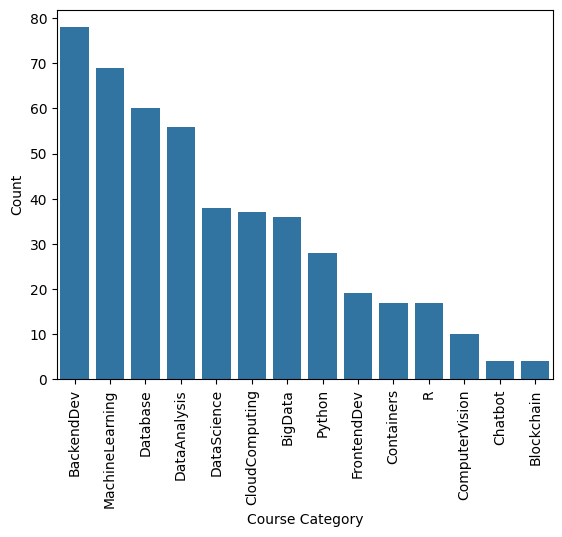

In [8]:
genre_sums = pd.DataFrame(course_df[genres].sum(axis=0), columns=["Count"]).sort_values(by="Count", ascending=False)

plot = sns.barplot(x=genre_sums.index, y="Count", data=genre_sums)
plot.set_xticklabels(plot.get_xticklabels(), rotation = 90)
plot.set_xlabel("Course Category")

## Course Enrolment

In [9]:
ratings_df.head(), ratings_df['rating'].unique(), ratings_df.shape[0]

(      user        item  rating
 0  1889878    CC0101EN       5
 1  1342067    CL0101EN       3
 2  1990814  ML0120ENv3       5
 3   380098    BD0211EN       5
 4   779563    DS0101EN       3,
 array([5, 3, 4], dtype=int64),
 233306)

In [10]:
ratings_count = pd.DataFrame(ratings_df.groupby(by="user").size().sort_values(ascending=False), columns = ["Count"])
ratings_count

,Count
user,
2,61
5,59
924030,51
1653994,51
1761291,50
...,...
891557,1
892174,1
892298,1


In [11]:
ratings_count.describe()

,Count
count,33901.000000
mean,6.881980
std,5.823548
min,1.000000
25%,2.000000
50%,6.000000
75%,9.000000
max,61.000000


Text(0.5, 0, 'Number of courses enrolled per student')

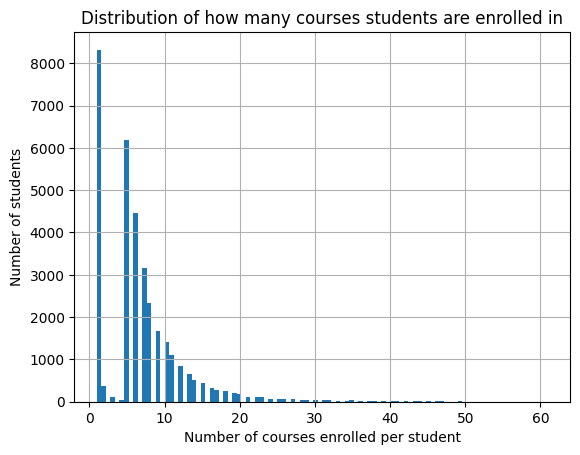

In [12]:
hist_plot = ratings_count.hist(bins=100)
plt.title("Distribution of how many courses students are enrolled in")
plt.ylabel("Number of students")
plt.xlabel("Number of courses enrolled per student")

## Finding the top 20 most popular courses

In [13]:
ratings_df.head()

,user,item,rating
0,1889878,CC0101EN,5
1,1342067,CL0101EN,3
2,1990814,ML0120ENv3,5
3,380098,BD0211EN,5
4,779563,DS0101EN,3


In [14]:
ratings_groupd_by_course_name = ratings_df.groupby(['item']).size().reset_index()
ratings_groupd_by_course_name.columns = ["Course", "Enrolls"]
top_20_courses = ratings_groupd_by_course_name.sort_values(by="Enrolls", ascending=False).reset_index(drop=True).head(20)

In [15]:
course_df.columns

Index(['COURSE_ID', 'TITLE', 'Database', 'Python', 'CloudComputing',
       'DataAnalysis', 'Containers', 'MachineLearning', 'ComputerVision',
       'DataScience', 'BigData', 'Chatbot', 'R', 'BackendDev', 'FrontendDev',
       'Blockchain'],
      dtype='object')

In [16]:
top_20_courses.merge(course_df[["COURSE_ID", "TITLE"]], how="left", left_on="Course", right_on="COURSE_ID")[["TITLE", "Enrolls"]]

,TITLE,Enrolls
0,python for data science,14936
1,introduction to data science,14477
2,big data 101,13291
3,hadoop 101,10599
4,data analysis with python,8303
5,data science methodology,7719
6,machine learning with python,7644
7,spark fundamentals i,7551
8,data science hands on with open source tools,7199
9,blockchain essentials,6719


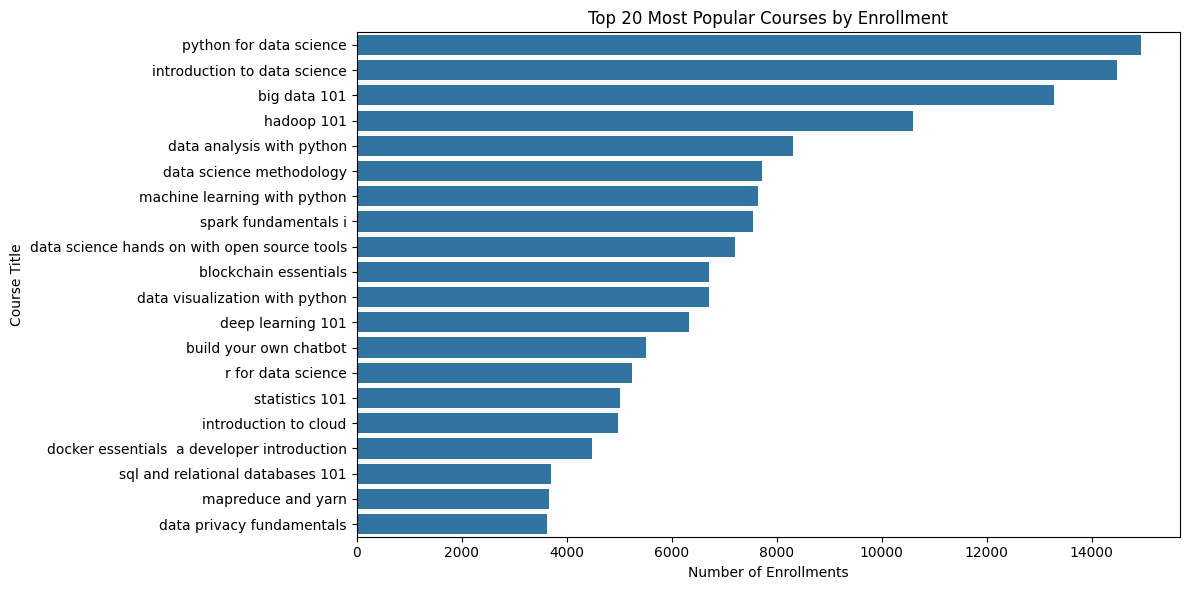

In [28]:
top_20_df = top_20_courses.merge(course_df[["COURSE_ID", "TITLE"]], how="left", left_on="Course", right_on="COURSE_ID")[["TITLE", "Enrolls"]]
plt.figure(figsize=(12, 6))
sns.barplot(x="Enrolls", y="TITLE", data=top_20_df, orient="h")
plt.xlabel("Number of Enrollments")
plt.ylabel("Course Title")
plt.title("Top 20 Most Popular Courses by Enrollment")
plt.tight_layout()

In [18]:
# Get the total course enrollments again
total = ratings_df.shape[0]
total

233306

In [19]:
top = top_20_courses["NumRatings"].sum()
top

KeyError: 'NumRatings'

In [ ]:
print(f"Percentage of the top course enrollments {round((top * 100)/total, 2)}%")

Percentage of the top course enrollments 63.3%
